## Notebook Setup

In [2]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gc
import torch
import types
import sys
import os
import json
import joblib
from pathlib import Path


from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
from numpy import float64
from sklearn.metrics import roc_auc_score
from utils.metrics.calculate_metric import calculate_agg_metric
from utils.set_random_seed import set_random_seed
# from interpret.glassbox import ExplainableBoostingClassifier
from utils.model_loaders import load_logistic_models_for_subfolder



set_random_seed(42)
EXPERIMENTS = ["experiment_1", "experiment_4", "experiment_54", "experiment_61", "experiment_73"]

INFO 03-30 21:21:25 [__init__.py:216] Automatically detected platform cuda.


In [3]:
## Load best param


best_params = {
    "judge": [],
    "groundtruth": []
}

for f in sorted(os.listdir("best_params")):
    _params = []
    results = json.load(open(f"best_params/{f}", "r"))["results"]
    for p in results:
        try:
            _params.append(p["best_params"])
        except KeyError:
            _params.append(None)
    
    if "judge" in f:
        best_params["judge"].append(_params)
    else:
        best_params["groundtruth"].append(_params)

In [4]:
def _get_split_sets(df, subfolder, split):
    split_df = df.filter((pl.col("subfolder") == subfolder) & (pl.col("split") == split))

    X_split = []
    y_split = []

    for exp in EXPERIMENTS:
        exp_df = split_df.filter(pl.col("experiment") == exp)

        X_exp = exp_df.select("input").to_numpy()
        X_exp = np.array([i[0] for i in X_exp])
        y_exp = exp_df.select("evaluation").to_numpy()

        # Data is interleaved: first 500 elements go to position 0 of each array,
        # next 500 elements go to position 1 of each array, etc.
        num_arrays = 500

        X_exp_reshaped = []
        y_exp_reshaped = []
        for i in range(num_arrays):
            # Take every 500th element starting from index i
            X_exp_reshaped.append(X_exp[i::num_arrays])
            y_exp_reshaped.append(y_exp[i::num_arrays])

        X_split.append(X_exp_reshaped)
        y_split.append(y_exp_reshaped)

    return X_split, y_split


def get_train_sets(df, subfolder):
    return _get_split_sets(df, subfolder=subfolder, split="train")


def get_test_sets(df, subfolder):
    return _get_split_sets(df, subfolder=subfolder, split="test")

In [5]:
df = []

for subfolder in ["voting", "rougel", "binary_judge"]:
    for exp in EXPERIMENTS:
        for split in ["train", "test"]:
            try:
                load_df = pl.read_ipc(f"binary_collections/{subfolder}/{exp}/{split}.feather")
                load_df = load_df.with_columns([
                    pl.lit(subfolder).alias("subfolder"),
                    pl.lit(exp).alias("experiment"),
                    pl.lit(split).alias("split"),
                ])
                df.append(load_df)
            except Exception as e:
                print(f"Could not load {subfolder}/{exp}/{split}: {e}")
df = pl.concat(df)
df.head()

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to 

collection_idx,test_idx,input,evaluation,subfolder,experiment,split
i64,i64,"array[i64, 32]",i32,str,str,str
0,0,"[0, 0, … 1]",0,"""voting""","""experiment_1""","""train"""
0,1,"[0, 0, … 1]",1,"""voting""","""experiment_1""","""train"""
0,2,"[0, 0, … 1]",0,"""voting""","""experiment_1""","""train"""
0,3,"[0, 0, … 1]",0,"""voting""","""experiment_1""","""train"""
0,4,"[0, 0, … 1]",1,"""voting""","""experiment_1""","""train"""


## Logistic Regression - Rougel
```

### Distribution Analysis

In [11]:
alt1_train = df.filter((pl.col("subfolder") == "rougel") & (pl.col("split") == "train"))
alt1_test = df.filter((pl.col("subfolder") == "rougel") & (pl.col("split") == "test"))


/tmp/ipykernel_3541123/638424063.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[0])
/tmp/ipykernel_3541123/638424063.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=test_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[1])


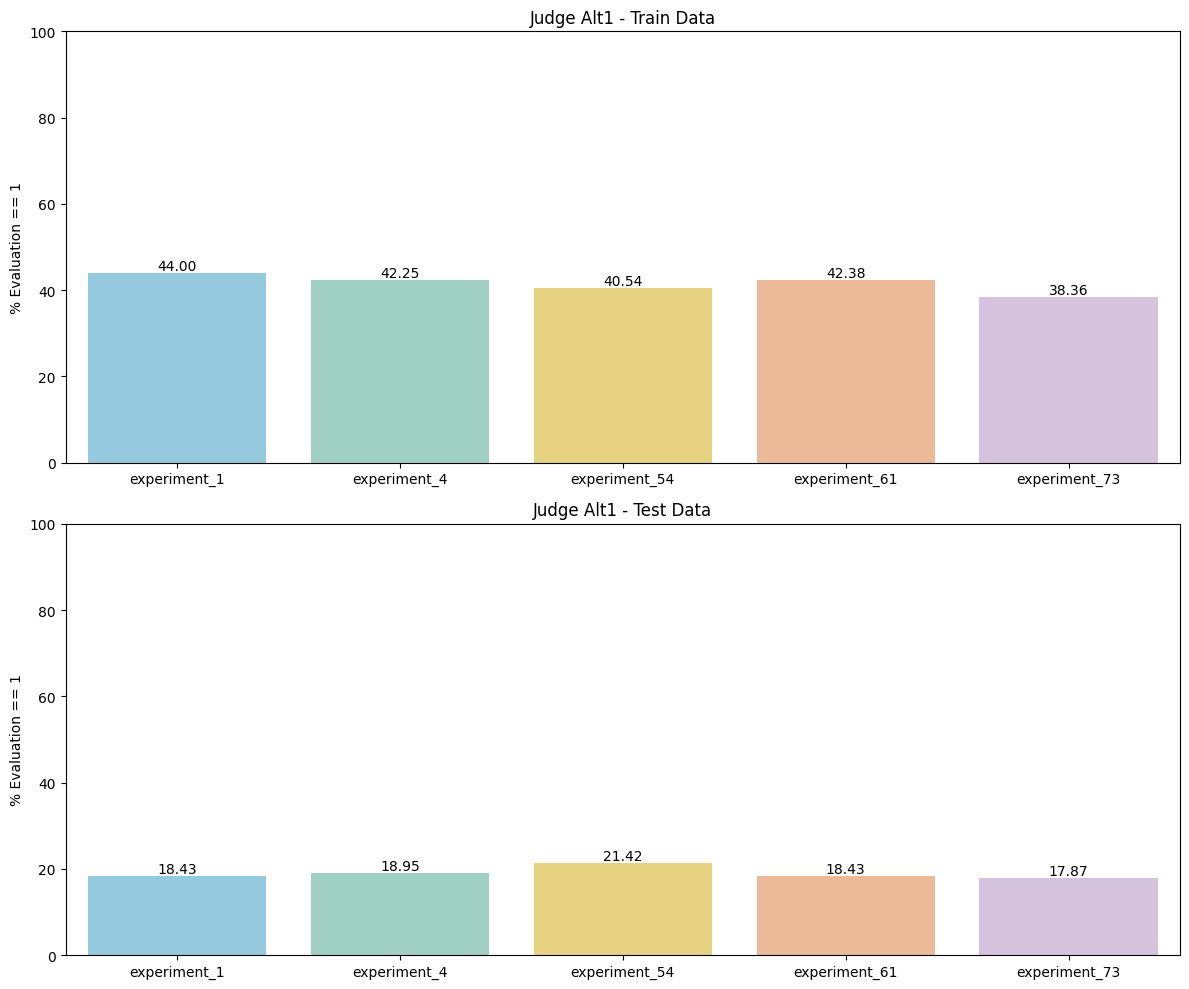

In [13]:
# Judge Analysis - % of evaluation == 1 for train and test
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Prepare data for train split
train_data = []
for exp in EXPERIMENTS:
    _exp = alt1_train.filter(pl.col("experiment") == exp)
    pct = (_exp.filter(pl.col("evaluation") == 1).height / _exp.height) * 100
    train_data.append({"experiment": exp, "percentage": pct})
train_df = pl.DataFrame(train_data)

# Plot train data
pastel_colors = ["#87CEEB", "#98D8C8", "#F7DC6F", "#F8B88B", "#D7BDE2"]  # Pastel colors
sns.barplot(data=train_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[0])
axes[0].set_title("Judge Alt1 - Train Data")
axes[0].set_ylabel("% Evaluation == 1")
axes[0].set_ylim(0, 100)
axes[0].set_xlabel("")

# Add value labels on top of bars
for patch in axes[0].patches:
    height = patch.get_height()
    axes[0].text(patch.get_x() + patch.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom')

# Prepare data for test split
test_data = []
for exp in EXPERIMENTS:
    _exp = alt1_test.filter(pl.col("experiment") == exp)
    pct = (_exp.filter(pl.col("evaluation") == 1).height / _exp.height) * 100
    test_data.append({"experiment": exp, "percentage": pct})
test_df = pl.DataFrame(test_data)

# Plot test data
sns.barplot(data=test_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[1])
axes[1].set_title("Judge Alt1 - Test Data")
axes[1].set_ylabel("% Evaluation == 1")
axes[1].set_ylim(0, 100)
axes[1].set_xlabel("")

# Add value labels on top of bars
for patch in axes[1].patches:
    height = patch.get_height()
    axes[1].text(patch.get_x() + patch.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Training Models

In [9]:
X_alt1_train, y_alt1_train = get_train_sets(df, "voting")
alt1_models = []



with tqdm(total=5 * 500, desc="Training models") as pbar:
    for i in range(5):
        _alt1_arr = []
        for j in range(500):
            # Alt1 model
            X_alt1 = X_alt1_train[i][j]
            y_alt1 = y_alt1_train[i][j].ravel()
            
            if best_params["judge"][i][j] is None:
                _alt1_arr.append(None)
            else:
                model_alt1 = LogisticRegression(**best_params["judge"][i][j], max_iter=1000, random_state=42)
                model_alt1.fit(X_alt1, y_alt1)
                _alt1_arr.append(model_alt1)
           
            


            
            pbar.update(1)
        
        alt1_models.append(_alt1_arr)

del X_alt1_train, y_alt1_train

Training models:   0%|                                                                                                                                           | 0/2500 [00:00<?, ?it/s]/home/users/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/users/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/users/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/users/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only

In [ ]:
for exp in range(len(EXPERIMENTS)):
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in alt1_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/alt1_weights.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in alt2_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/alt2_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in alt1_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/alt1_bias.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in alt2_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/alt2_bias.pt")


### saving for datamodels generations
for exp in range(len(EXPERIMENTS)):
    alt1_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/alt1/"
    alt2_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/alt2/"
    os.makedirs(alt2_path, exist_ok=True)
    os.makedirs(alt1_path, exist_ok=True)

    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in alt1_models[exp]]), f"{alt1_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in alt2_models[exp]]), f"{alt2_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in alt1_models[exp]]), f"{alt1_path}/0_499_bias.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in alt2_models[exp]]), f"{alt2_path}/0_499_bias.pt")

/tmp/ipykernel_1013027/537923468.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in alt1_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/alt1_bias.pt")
/tmp/ipykernel_1013027/537923468.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in alt2_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/alt2_bias.pt")
/tmp/ipykernel_1013027/537923468.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensu

In [11]:
LOAD = True
if LOAD:
    alt1_models = load_logistic_models_for_subfolder("judge", "alt1_weights.pt", "alt1_bias.pt", experiments=EXPERIMENTS)
    alt2_models = load_logistic_models_for_subfolder("judge", "alt2_weights.pt", "alt2_bias.pt", experiments=EXPERIMENTS)

In [10]:
X_alt1_test, y_alt1_test = get_test_sets(df, "alt1")


_eval_df = {
    "experiment": [],
    "type": [],
    "auc": [],
}


for i in range(5):
    for j in range(500):
        
        alt1_lr = alt1_models[i][j]
        if alt1_lr is not None:

            _x = X_alt1_test[i][j]
            _y = y_alt1_test[i][j].ravel()
            score = roc_auc_score(_y, alt1_lr.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("alt1")
            _eval_df["auc"].append(score)


del X_alt1_test, y_alt1_test
gc.collect()

/home/users/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


984

In [11]:
eval_df = pl.DataFrame(_eval_df)    
eval_df.filter(pl.col("auc").is_not_nan()).group_by("type").agg(pl.col("auc").mean().alias("mean_auc"), pl.col("auc").std().alias("std_auc"))

type,mean_auc,std_auc
str,f64,f64
"""alt1""",0.509842,0.065172


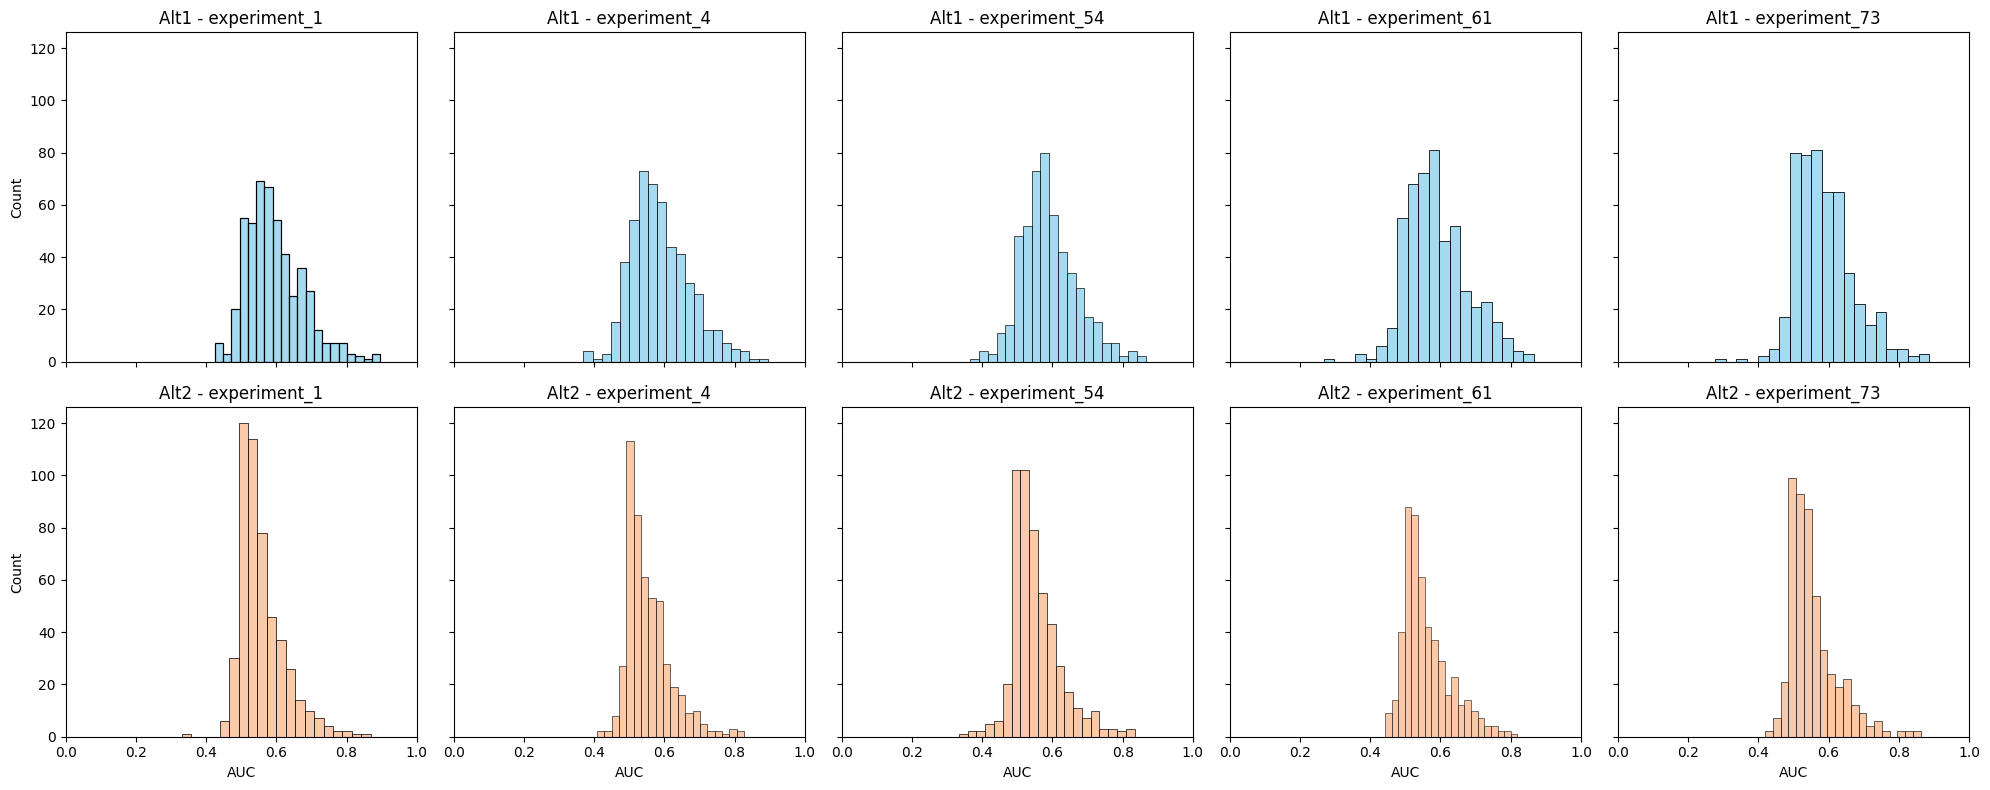

In [17]:
# Plot AUC histograms per type/experiment using existing eval_df (Polars)
import seaborn as sns
import matplotlib.pyplot as plt

eval_df = pl.DataFrame(_eval_df)    
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
color_map = {"alt1": "#87CEEB", "alt2": "#F8B88B"}  # Pastel blue, pastel orange

for row, t in enumerate(["alt1", "alt2"]):
    for col, exp in enumerate(EXPERIMENTS):
        subset = eval_df.filter((pl.col("type") == t) & (pl.col("experiment") == exp))
        sns.histplot(data=subset.to_pandas(), x="auc", bins=20, color=color_map[t], ax=axes[row, col])
        axes[row, col].set_title(f"{t.capitalize()} - {exp}")
        axes[row, col].set_xlim(0, 1)
        if col == 0:
            axes[row, col].set_ylabel("Count")
        else:
            axes[row, col].set_ylabel("")
        axes[row, col].set_xlabel("AUC")

plt.tight_layout()
plt.show()

### Text Generation Results

In [6]:
wiki = pl.read_ipc(f"../../data/wiki_dump2018_nq_open/processed/wiki.feather")
gold = pl.read_ipc(f"../../data/nq_open_gold/processed/dev.feather")

generations = ["binary_judge", "rougel", "voting", "rag", "zeroshot"]

LOAD = False
if not LOAD:
    dfs_generations = []
    for exp in EXPERIMENTS:
        questions_path = f"runs/{exp}/questions.feather"
        for file in os.listdir(f"runs/{exp}/generations"):
            for gen_prefix in generations:
                if gen_prefix in file:
                    print(f"Processing {file} for experiment {exp}...")
                    dfs_generations.append(calculate_agg_metric(
                        metrics=["rouge_l", "squad_v2_best_f1", "squad_v2_best_exact"],
                        generation_path=f"runs/{exp}/generations/{file}",
                        reference_path=questions_path    ,
                        saving_path=None            
                    )
                    .with_columns([
                        pl.lit(exp).alias("experiment"),
                        pl.lit(gen_prefix).alias("generation_method"),
                    ]))

    generations_results = pl.concat(dfs_generations)
    generations_results.write_ipc("generation_results/results.feather")
else:
    generations_results = pl.read_ipc("generation_results/results.feather")

Processing rougel.json for experiment experiment_1...
Calculating rouge_l...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Using the latest cached version of the module from /home/caio.rhoden/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--rouge/b01e0accf3bd6dd24839b769a5fda24e14995071570870922c71970b3a6ed886 (last modified on Wed Oct 16 22:50:24 2024) since it couldn't be found locally at evaluate-metric--rouge, or remotely on the Hugging Face Hub.


Calculating squad_v2_best_f1...


Calculating squad_v2_best_exact...


Processing binary_judge.json for experiment experiment_1...
Calculating rouge_l...


...

Calculating squad_v2_best_exact...


Processing rougel.json for experiment experiment_73...
Calculating rouge_l...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Calculating squad_v2_best_f1...


Calculating squad_v2_best_exact...


In [8]:
generations_results.filter(pl.col("metric")=="rouge_l").group_by("generation_method").agg(pl.col("value").mean().alias("mean_rouge_l"), pl.col("value").std().alias("std_rouge_l"))

generation_method,mean_rouge_l,std_rouge_l
str,f32,f32
"""voting""",0.412256,0.43379
"""rag""",0.444026,0.436682
"""zeroshot""",0.2018,0.345387
"""binary_judge""",0.413898,0.436732
"""rougel""",0.580784,0.413036


In [ ]:
# Distribution plots for metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROUGE-L Distribution
rouge_l_data = generations_results.filter(pl.col("metric") == "rouge_l")
sns.histplot(data=rouge_l_data.to_pandas(), x="value", bins=30, kde=True, ax=axes[0], color="#87CEEB")
axes[0].set_title("ROUGE-L Distribution", fontsize=12, fontweight='bold')
axes[0].set_xlabel("ROUGE-L Score")
axes[0].set_ylabel("Frequency")
axes[0].axvline(rouge_l_data.select("value").mean()[0, 0], color='red', linestyle='--', label=f"Mean: {rouge_l_data.select('value').mean()[0, 0]:.4f}")
axes[0].legend()

# SQuAD v2 Exact Match Distribution
exact_data = generations_results.filter(pl.col("metric") == "squad_v2_best_exact")
sns.histplot(data=exact_data.to_pandas(), x="value", bins=30, kde=True, ax=axes[1], color="#F8B88B")
axes[1].set_title("SQuAD v2 Exact Match Distribution", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Exact Match Score")
axes[1].set_ylabel("Frequency")
axes[1].axvline(exact_data.select("value").mean()[0, 0], color='red', linestyle='--', label=f"Mean: {exact_data.select('value').mean()[0, 0]:.4f}")
axes[1].legend()

# SQuAD v2 F1 Distribution
f1_data = generations_results.filter(pl.col("metric") == "squad_v2_best_f1")
sns.histplot(data=f1_data.to_pandas(), x="value", bins=30, kde=True, ax=axes[2], color="#98D8C8")
axes[2].set_title("SQuAD v2 F1 Distribution", fontsize=12, fontweight='bold')
axes[2].set_xlabel("F1 Score")
axes[2].set_ylabel("Frequency")
axes[2].axvline(f1_data.select("value").mean()[0, 0], color='red', linestyle='--', label=f"Mean: {f1_data.select('value').mean()[0, 0]:.4f}")
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Box plots by generation method
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROUGE-L Box plots
rouge_l_data = generations_results.filter(pl.col("metric") == "rouge_l").to_pandas()
sns.boxplot(data=rouge_l_data, x="generation_method", y="value", ax=axes[0], palette="Set2")
axes[0].set_title("ROUGE-L by Generation Method", fontsize=12, fontweight='bold')
axes[0].set_ylabel("ROUGE-L Score")
axes[0].set_xlabel("Generation Method")
axes[0].tick_params(axis='x', rotation=45)

# SQuAD v2 Exact Match Box plots
exact_data = generations_results.filter(pl.col("metric") == "squad_v2_best_exact").to_pandas()
sns.boxplot(data=exact_data, x="generation_method", y="value", ax=axes[1], palette="Set2")
axes[1].set_title("SQuAD v2 Exact Match by Generation Method", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Exact Match Score")
axes[1].set_xlabel("Generation Method")
axes[1].tick_params(axis='x', rotation=45)

# SQuAD v2 F1 Box plots
f1_data = generations_results.filter(pl.col("metric") == "squad_v2_best_f1").to_pandas()
sns.boxplot(data=f1_data, x="generation_method", y="value", ax=axes[2], palette="Set2")
axes[2].set_title("SQuAD v2 F1 by Generation Method", fontsize=12, fontweight='bold')
axes[2].set_ylabel("F1 Score")
axes[2].set_xlabel("Generation Method")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [12]:
generations_results.filter(pl.col(name="metric")=="squad_v2_best_exact").group_by("generation_method").agg(pl.col("value").mean().alias("mean_squad_v2_best_exact"), pl.col("value").std().alias("std_squad_v2_best_exact"))

generation_method,mean_squad_v2_best_exact,std_squad_v2_best_exact
str,f32,f32
"""rag""",0.3152,0.464688
"""zeroshot""",0.1136,0.317388
"""voting""",0.2844,0.451218
"""binary_judge""",0.294,0.455683
"""rougel""",0.4088,0.491711


In [10]:
generations_results.filter(pl.col(name="metric")=="squad_v2_best_f1").group_by("generation_method").agg(pl.col("value").mean().alias("mean_rouge_l"), pl.col("value").std().alias("std_rouge_l"))

generation_method,mean_rouge_l,std_rouge_l
str,f32,f32
"""voting""",0.406974,0.436472
"""binary_judge""",0.40792,0.440302
"""rougel""",0.570279,0.420559
"""zeroshot""",0.196957,0.346501
"""rag""",0.438423,0.439588
